# CD Temperature Scan Lab Notebook

This notebook explains how to analyze circular dichroism (CD) temperature-scan data for protein thermal stability.

The workflow includes:
- loading raw wavelength-specific temperature scan files,
- building a 2D Temperature × Wavelength dataset,
- filtering poor-quality absorbance data,
- plotting unfolding curves,
- fitting multiple models to extract melting temperatures (Tm),
- and combining wavelength-specific estimates into a final result.

If the introduction is missing in your viewer, refresh the notebook after saving this cell.

# Thermal Stability Analysis via CD Temperature Scans

This notebook analyzes protein thermal stability using temperature-dependent CD measurements. 

## Overview
We measure CD spectra at multiple temperatures and wavelengths, then fit models to extract the melting temperature (Tm) - the temperature at which the protein is 50% unfolded.

**Key Features:**
- Loads multiple CSV files (one per wavelength)
- Organizes data into a 2D temperature-wavelength matrix (xarray)
- Tests different fitting models
- Extracts Tm values and estimates uncertainty

**Watch out for data structure complexity and outliers!**

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import numpy as np
from scipy.optimize import curve_fit

In [7]:
%pip install xarray

Note: you may need to restart the kernel to use updated packages.


## Step 1: Import Libraries

Essential imports for temperature scan analysis:
- `pandas` for data manipulation
- `numpy` for numerical operations
- `scipy.optimize.curve_fit` for fitting models to data
- `scipy.signal.savgol_filter` for smoothing noisy derivatives

In [8]:
protein_name = "ppBAT"

## Step 2: Set Protein Name

Change this to match your protein sample.

In [9]:
base_directory = "/home/christoph/Nextcloud/Documents/Work/Bastian_Vertretung/Biophysikalische_Methoden/Prakt"
tempscan_directory = os.path.join(base_directory, "ppBat00008_tempscan/")

## Step 3: Set Data Paths

Point to the directory containing temperature scan files. Expected structure:
- Each wavelength gets its own CSV file (e.g., `Myo00004 200nm.csv`)
- Temperature files (e.g., `Myo00004 20.3193C.csv`)

In [10]:
# write a file list for the tempscan directory
tempscan_files = [f for f in os.listdir(tempscan_directory) if f.endswith('.csv')]
tempscan_files.sort()
wl_files = []
temp_files = []

for file in tempscan_files:
    descriptor = file.split(' ')[-1]
    if descriptor.endswith('nm.csv'):
        wavelength = int(descriptor.split('nm')[0])
        wl_files.append((file, wavelength))
    elif descriptor.endswith('C.csv'):
        temp_files.append(file)

# for file, wavelength in wl_files:
#     print(f"Wavelength file: {file}, Wavelength: {wavelength}")

## Step 4: Organize Files by Type

Separate wavelength files (e.g., `200nm.csv`) from temperature files (e.g., `20.3193C.csv`). 

**Data structure created:**
- `wl_files`: List of tuples `(filename, wavelength_int)` - one spectrum per wavelength
- `temp_files`: Temperature-dependent files (not used in this analysis)

In [11]:
# read a wavelength file, find the data part (after the line 'Data:' and store it in a dataframe
def read_tempscan(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
        data_start_index = None
        for i, line in enumerate(lines):
            if line.strip() == 'Data:':
                data_start_index = i + 1
                break
        if data_start_index is None:
            raise ValueError("Data section not found in the file.")
        data_lines = lines[data_start_index:]
        data = [line.strip().split(',') for line in data_lines if line.strip()]
        df = pd.DataFrame(data[1:], columns=data[0])
        # strip last column
        df = df.loc[:, df.columns != '']
        df = df.apply(pd.to_numeric)
        return df
    

## Step 5: Define Data Reading Function

Each CSV file contains a header followed by a "Data:" separator. This function:
1. Locates the "Data:" line
2. Reads the subsequent table
3. Converts to numeric types

**Note:** The file format is specific to the spectrometer used. Files contain Temperature, CircularDichroism, HV, Absorbance columns.

In [12]:
all_data = []

for file_name, wavelength in wl_files:
    df = read_tempscan(os.path.join(tempscan_directory, file_name))

    df["wavelength"] = wavelength  # ← key step

    all_data.append(df)

all_data[0]

,Temperature,CircularDichroism,HV,Absorbance,Voltage,Count,wavelength
0,20.8689,6.13988,645.920,1.27382,7.94042,10000,195
1,20.6691,6.32101,645.630,1.27309,7.92600,10000,195
2,20.8190,5.81939,645.401,1.27321,7.90208,10000,195
3,21.1186,5.78388,646.301,1.27441,7.96582,10000,195
4,21.4182,6.22640,645.905,1.27592,7.90057,10000,195
...,...,...,...,...,...,...,...
144,89.1730,5.19535,777.969,1.91008,7.95926,10000,195
145,89.7070,5.50650,779.572,1.91786,7.95634,10000,195
146,90.1924,4.06509,781.036,1.92514,7.94866,10000,195
147,90.6778,6.08146,782.593,1.93433,7.91160,10000,195


## Step 6: Combine All Wavelengths

**Critical step!** Each file gives CD vs. Temperature at one wavelength. Add a "wavelength" column to each DataFrame, then concatenate all.

**Result:** `all_data` is a list of DataFrames, where each row contains Temperature, CD, HV, Absorbance, and wavelength.

In [13]:
full_df = pd.concat(all_data, ignore_index=True)

full_df

,Temperature,CircularDichroism,HV,Absorbance,Voltage,Count,wavelength
0,20.8689,6.13988,645.920,1.273820,7.94042,10000,195
1,20.6691,6.32101,645.630,1.273090,7.92600,10000,195
2,20.8190,5.81939,645.401,1.273210,7.90208,10000,195
3,21.1186,5.78388,646.301,1.274410,7.96582,10000,195
4,21.4182,6.22640,645.905,1.275920,7.90057,10000,195
...,...,...,...,...,...,...,...
5359,88.8819,-6.57093,456.314,0.262749,7.97558,10000,230
5360,89.4157,-6.44755,456.802,0.263172,8.01566,10000,230
5361,89.9011,-6.16655,456.848,0.261868,8.04427,10000,230
5362,90.3866,-5.88560,457.047,0.263450,8.03444,10000,230


Concatenate all wavelength DataFrames into one large DataFrame.

**Data structure:** Each row is (Temperature, wavelength) with CD, HV, Absorbance values.

In [14]:
dedup_av_full_df = full_df.groupby(["Temperature", "wavelength"]).mean().reset_index()

duplicates = full_df[full_df.duplicated(subset=["Temperature", "wavelength"], keep=False)]

print("length of the original DataFrame:", len(full_df))
print("length of the deduplicated DataFrame:", len(dedup_av_full_df))
print(duplicates)

length of the original DataFrame: 5364
length of the deduplicated DataFrame: 5361
      Temperature  CircularDichroism       HV  Absorbance  Voltage  Count  \
2831      20.9688           -8.86515  498.810    0.330737  7.97124  10000   
2834      20.9688           -8.28706  498.917    0.332011  7.95476  10000   
2980      20.9688           -8.35893  493.958    0.317845  7.92373  10000   
2983      20.9688           -7.84967  494.873    0.318674  7.96948  10000   
3278      20.9688           -8.37764  486.313    0.291114  7.95289  10000   
3281      20.9688           -7.98470  486.420    0.293156  7.92317  10000   

      wavelength  
2831         214  
2834         214  
2980         215  
2983         215  
3278         217  
3281         217  


## Step 7: Handle Duplicates

**Pitfall Alert!** If the same (Temperature, wavelength) combination appears multiple times, we average them.

The spectrometer may measure the same condition multiple times. This step:
1. Groups by (Temperature, wavelength)
2. Averages all measurements for each group
3. Reports how many duplicates were found

Check the printed output - if many duplicates exist, investigate your data!

In [15]:
temperature_array = dedup_av_full_df.set_index(["Temperature", "wavelength"]).to_xarray()

## Step 8: Convert to xarray

**Important data structure change!**

Converting to xarray creates a multi-dimensional array indexed by Temperature and wavelength. This allows:
- Easy selection of data at specific wavelengths or temperatures
- Vectorized operations across dimensions
- Cleaner plotting

**xarray structure:**
- Dimensions: `Temperature` and `wavelength`
- Variables: `CircularDichroism`, `HV`, `Absorbance`
- Access like: `temperature_array["CircularDichroism"].sel(wavelength=222)`

This is more powerful but also more complex than pandas!

In [16]:
print(temperature_array)

<xarray.Dataset> Size: 1MB
Dimensions:            (Temperature: 960, wavelength: 36)
Coordinates:
  * Temperature        (Temperature) float64 8kB 20.67 20.72 ... 91.11 91.16
  * wavelength         (wavelength) int64 288B 195 196 197 198 ... 228 229 230
Data variables:
    CircularDichroism  (Temperature, wavelength) float64 276kB 6.321 ... nan
    HV                 (Temperature, wavelength) float64 276kB 645.6 ... nan
    Absorbance         (Temperature, wavelength) float64 276kB 1.273 ... nan
    Voltage            (Temperature, wavelength) float64 276kB 7.926 ... nan
    Count              (Temperature, wavelength) float64 276kB 1e+04 ... nan


Inspect the xarray structure. Shows all dimensions, coordinates, and variables.

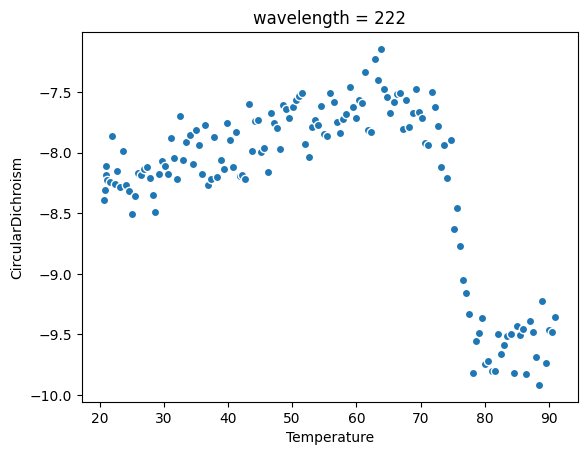

In [17]:
display_wavelength = 222

temperature_array["CircularDichroism"].sel(wavelength=display_wavelength).where(temperature_array["Absorbance"].sel(wavelength=display_wavelength) <= 2).plot.scatter()

## Step 9: Select and Plot Single Wavelength

Example: Select CD data at 222 nm (a strong alpha-helix signature wavelength in the far-UV). 

Here the data structure is an issue. there are many temperature points that do not have a CD value associated to it. This is due to the measurement technique where the temperature is measured very precisely for each CD-value at each wavelength. Matplotlib struggles here to display this properly as the standard lineplot. Be sure to use .plot.scatter() or preselect the datapoints and drop NaNs before plotting as shown in the next cell.

In both cases you can directly filter out data that has absorbance values above a threshold.

The `.sel()` method (select) is the xarray way to slice data - much cleaner than boolean indexing!

In [18]:
sel = temperature_array["CircularDichroism"].sel(wavelength=222).where(temperature_array["Absorbance"].sel(wavelength=222) <= 2)

print(sel.notnull().sum().item())
print(sel.shape)
print(sel.isnull().sum().item())
sel = sel.dropna("Temperature", how="all")

sel.plot()

149
(960,)
811


## Step 10: Apply Quality Filter

**Pitfall Alert!** High absorbance (>2 AU) can distort CD measurements. 

This cell:
1. Selects CD at 200 nm where absorbance <= 2
2. Uses `.where()` to mask bad data (sets them to NaN)
3. Uses `.dropna()` to remove all-NaN dimensions

**Beware:** `.where()` keeps the structure but fills with NaN; `.dropna()` removes those entries. The order matters!

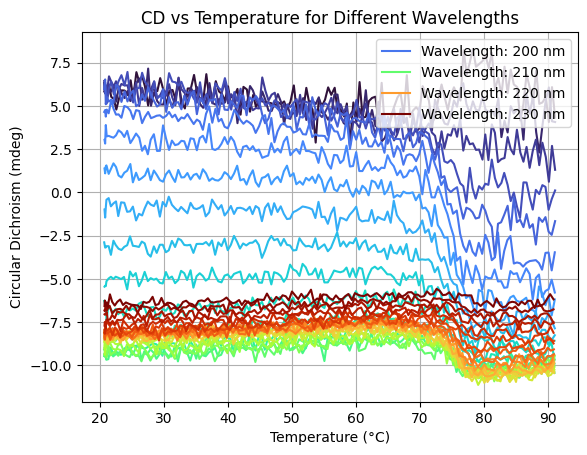

In [19]:
# wavelengths = temperature_array.wavelength.values
cmap = plt.cm.turbo   # or plasma, inferno, etc.

for i, wavelength in enumerate(wl_files):

    color = cmap(i / (len(wl_files)-1))

    sel = temperature_array["CircularDichroism"].sel(wavelength=wavelength[1]).where(temperature_array["Absorbance"].sel(wavelength=wavelength[1]) <= 2)
    sel = sel.dropna("Temperature", how="all")
    if not sel.any():
        continue
    if np.mod(wavelength[1], 10) == 0:
        sel.plot(label=f"Wavelength: {wavelength[1]} nm", color=color)
    else:
        sel.plot(color=color)
plt.xlabel("Temperature (°C)")
plt.ylabel("Circular Dichroism (mdeg)")
# plt.ylim(-10,10)
plt.title("CD vs Temperature for Different Wavelengths")
plt.legend(loc='upper right')
plt.grid()
plt.show()

## Step 11: Plot CD Temperature Profiles

Loop through all wavelengths and plot CD vs. Temperature. This reveals thermal unfolding signatures.

- Only plot wavelengths with data (`.any()` check). If the filter removes all the data the plotting would crash otherwise.
- Label every 10th wavelength for clarity
- The characteristic unfolding curve should show: folded → transition → unfolded states

/tmp/ipykernel_3554557/142607321.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


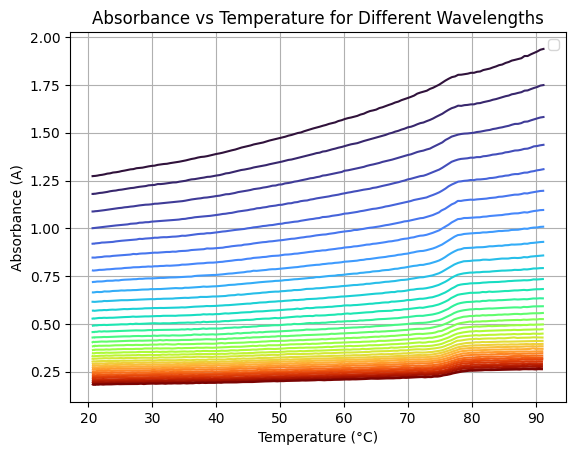

In [20]:

for i, wavelength in enumerate(wl_files):
    color = cmap(i / (len(wl_files)-1)) 
    Abs_sel = temperature_array["Absorbance"].sel(wavelength=wavelength[1]).dropna("Temperature", how="all")
    Abs_sel.plot(color=color)

plt.xlabel("Temperature (°C)")
plt.ylabel("Absorbance (A)")
# plt.ylim(0,3)
plt.title("Absorbance vs Temperature for Different Wavelengths")
plt.legend(loc='upper right')
plt.grid()
plt.show()

## Step 12: Monitor Absorbance vs. Temperature

High absorbance at low wavelengths increases with temperature. This constrains the usable spectral range for thermal analysis.

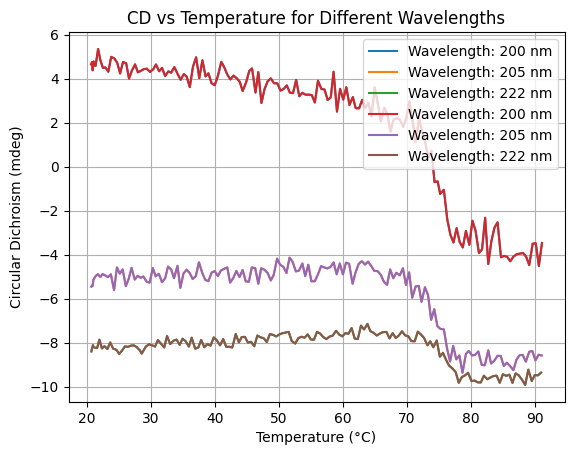

In [22]:
display_wls = [200, 222, 205]
display_wls.sort()


for wavelength in display_wls:
    sel = temperature_array["CircularDichroism"].sel(wavelength=wavelength)
    sel = sel.dropna("Temperature", how="all")
    sel.plot(label=f"Wavelength: {wavelength} nm")
    
plt.xlabel("Temperature (°C)")
plt.ylabel("Circular Dichroism (mdeg)")
plt.title("CD vs Temperature for Different Wavelengths")
plt.legend(loc='upper right')
plt.grid()
plt.show()

Plot selected wavelengths for clearer visualization of the unfolding transition.

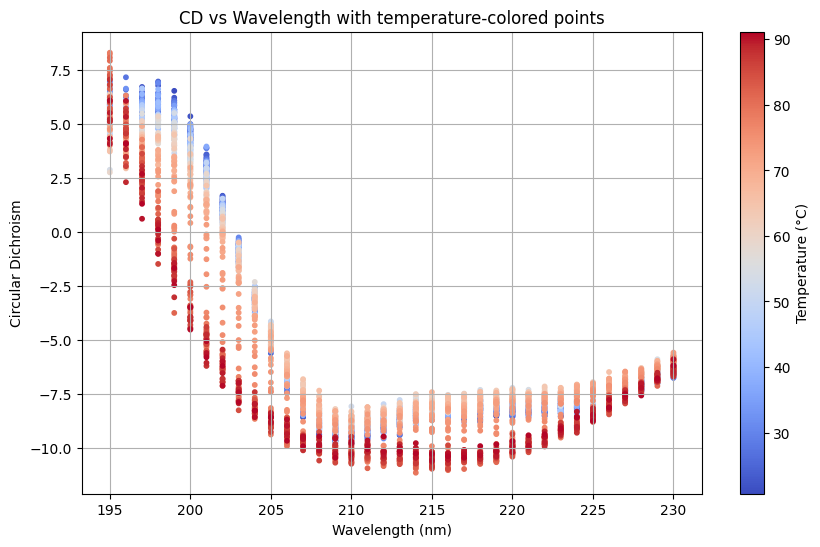

In [23]:
tmp = temperature_array["CircularDichroism"].where(temperature_array["Absorbance"] <= 2).to_dataframe().reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(
    tmp["wavelength"],
    tmp["CircularDichroism"],
    c=tmp["Temperature"],
    cmap="coolwarm",
    s=10
)
plt.colorbar(label="Temperature (°C)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Circular Dichroism")
# plt.ylim(-12,12)
plt.title("CD vs Wavelength with temperature-colored points")
plt.grid(True)
plt.show()

## Step 13: 2D Heatmap of CD Data

Visualize the entire Wavelength × CD space. Colors represent the measured temperature.

- X-axis: wavelength
- Y-axis: CD
- Color: measured temperature
- Only points with Absorbance < 2 are shown

This reveals which wavelengths show the strongest thermal transitions.

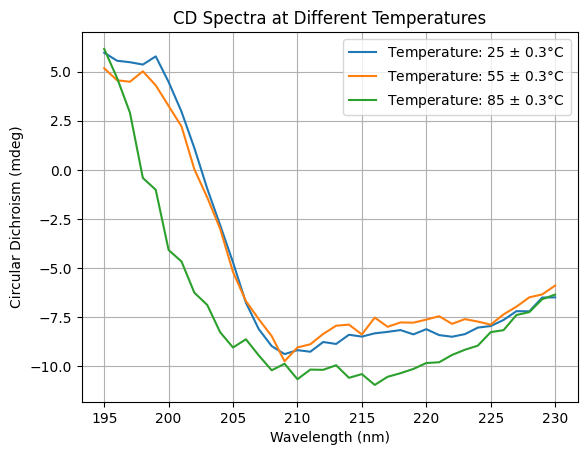

In [24]:
temp = [25, 55, 85]
temp.sort()
tolerance = 0.3
for t in temp:
    spec = temperature_array["CircularDichroism"].sel(Temperature=slice(t-tolerance, t+tolerance)).mean(dim="Temperature")
    spec.plot(label=rf'Temperature: {t} $\pm$ {tolerance}°C')

plt.xlabel("Wavelength (nm)")
plt.ylabel("Circular Dichroism (mdeg)")
plt.title("CD Spectra at Different Temperatures")
plt.legend()
plt.grid()
plt.show()

## Step 14: Extract Spectra at Selected Temperatures

Use `.sel(Temperature=slice(...))` with a tolerance. This is needed as almost every wavelength-CD pair is measured at a slightly different temperature. A good starting value for the tolerance is the set temperature ramp. If the temperature increase during one spectra measurement is expected to be 0.6 °C a tolerance of 0.3 °C should give decent spectra.

**Data structure:** At each temperature, average all scans within ±tolerance to get a representative spectrum.

In [25]:
curve = temperature_array["CircularDichroism"].sel(wavelength=222).dropna("Temperature")
curve = curve.sortby("Temperature")

T = curve["Temperature"].values
Y = curve.values


## Step 15: Model Fitting - Setup

Different models can be used to extract Tm from a CD vs. Temperature curve. Each has assumptions and pitfalls.

Extract CD curve at 222 nm (alpha-helix indicator) and prepare for fitting:
1. Get Temperature and CD signal arrays
2. Sort by temperature
3. Ready for model comparison

In [26]:
# prepare a dictionary to store the fit results

model_comparison = {}

Dictionary to store comparison data for all tested models.

# Simple Sigmoid fitting model

In [107]:
def simple_sigmoid(T, Tm, k, A, B):
    return A + B / (1 + np.exp((Tm - T)/k))

p0_sig = [
    70,  # Tm (from derivative!)
    2.0,                              # k (typical range 1–5)
    np.average(Y[1:10]),                          # A (lower baseline)
    np.average(Y[1:10]) - np.average(Y[-10:-1])                # B (amplitude)
]

**Model 1: Simple Sigmoid**

Assumes protein unfolds as a 2-state transition: Folded ↔ Unfolded

Equation: $CD(T) = A + \frac{B}{1 + e^{\frac{T_m - T}{k}}}$

Parameters:
- `Tm`: Melting temperature (the Tm!)
- `k`: Slope steepness (kB·T in thermal units)
- `A`: Lower baseline (folded state)
- `B`: Amplitude (signal difference)

**Pitfall:** Especially sloping baselines/end points can make trouble.

In [91]:
popt_sigmoid, pcov_sigmoid = curve_fit(simple_sigmoid, T, Y, p0=p0_sig, maxfev=10000)

Tm_fit_sigmoid, k_fit_sigmoid, A_fit_sigmoid, B_fit_sigmoid = popt_sigmoid

print(f"Fitted Tm: {Tm_fit_sigmoid:.2f} °C")

Fitted Tm: 75.99 °C


Fit the simple sigmoid to the full data. Compare with later models!

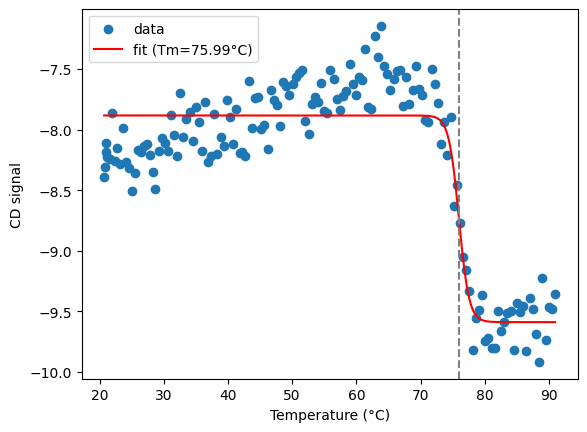

In [92]:
T_fit_sigmoid = np.linspace(T.min(), T.max(), 300)
Y_fit_sigmoid = simple_sigmoid(T_fit_sigmoid, *popt_sigmoid)

plt.scatter(T, Y, label="data")
plt.plot(T_fit_sigmoid, Y_fit_sigmoid, label=f"fit (Tm={Tm_fit_sigmoid:.2f}°C)", color='red')
plt.legend()
plt.xlabel("Temperature (°C)")
plt.ylabel("CD signal")
plt.axvline(Tm_fit_sigmoid, color='gray', linestyle='--', label=f'Tm = {Tm_fit_sigmoid:.2f}°C')

# add to the model comparison dictionary with the key "Sigmoid" the Tm value, and the T_fit_sigmoid and Y_fit_sigmoid as one dataframe
model_comparison["Sigmoid"] = {
    "Tm": Tm_fit_sigmoid,
    "T_fit": T_fit_sigmoid,
    "Y_fit": Y_fit_sigmoid
}
plt.show()

Plot the simple sigmoid fit. Store Tm in the comparison dict.

# Constrained sigmoid model

In [101]:
mask = (T > 60) & (T < 90)
T_fit_sig_con = T[mask]
Y_fit_sig_con = Y[mask]

p0_sig_con = [
    70,  # Tm (from derivative!)
    2.0,                              # k (typical range 1–5)
    np.average(Y_fit_sig_con[1:10]),                          # A (lower baseline)
    np.average(Y_fit_sig_con[1:10]) - np.average(Y_fit_sig_con[-10:-1])                # B (amplitude)
]

popt_sigmoid_con, pcov_sigmoid_con = curve_fit(simple_sigmoid, T_fit_sig_con, Y_fit_sig_con, p0=p0_sig_con, maxfev=10000)

Tm_fit_sigmoid_con, k_fit_sigmoid_con, A_fit_sigmoid_con, B_fit_sigmoid_con = popt_sigmoid_con

print(f"Fitted Tm: {Tm_fit_sigmoid_con:.2f} °C")

model_comparison["Sigmoid Constrained"] = {
    "Tm": Tm_fit_sigmoid_con,
    "T_fit": T_fit_sig_con,
    "Y_fit": Y_fit_sig_con
}

Fitted Tm: 75.53 °C


**Model 2: Constrained Sigmoid**

If the upper plateau doesn't reach completion (e.g., protein aggregates or denatures before fully unfolding) or initial baseline shifts, fit only the transition region (75-90°C here).

**Pitfall Alert!** This is dangerous - you're forcing a model on only part of the data. Use only when high-temperature data is clearly unreliable or missing or the initial baseline is sloping. If you have prior knowledge and a rough estimation of the transition temperature it might give good results but is therefore less general.

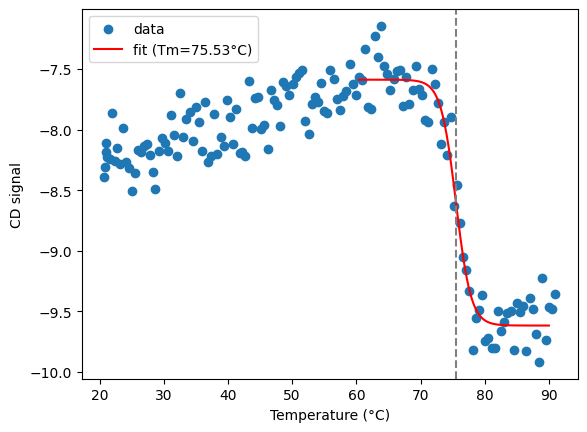

In [97]:
T_fit_sigmoid_con = np.linspace(T_fit_sig_con.min(), T_fit_sig_con.max(), 300)
Y_fit_sigmoid_con = simple_sigmoid(T_fit_sigmoid_con, *popt_sigmoid_con)

plt.scatter(T, Y, label="data")
plt.plot(T_fit_sigmoid_con, Y_fit_sigmoid_con, label=f"fit (Tm={Tm_fit_sigmoid_con:.2f}°C)", color='red')
plt.legend()
plt.xlabel("Temperature (°C)")
plt.ylabel("CD signal")
plt.axvline(Tm_fit_sigmoid_con, color='gray', linestyle='--', label=f'Tm = {Tm_fit_sigmoid_con:.2f}°C')
plt.show()

Plot the constrained sigmoid result. Likely shows different Tm than the full-range fit.

# Sigmoid model with slopes

In [32]:
def sigmoid_slope(T, Tm, k, mf, bf, mu, bu):
    exp_term = np.exp((T - Tm) / k)
    return ((mf*T + bf) + (mu*T + bu)*exp_term) / (1 + exp_term)

p0_sig_slope = [
    np.median(T),        # Tm
    1.0,                 # k
    0.0, Y.min(),        # folded baseline (mf, bf)
    0.0, Y.max()         # unfolded baseline (mu, bu)
]


**Model 3: Sigmoid with Linear Slopes**

Proteins often show linear changes in CD above and below the transition (e.g., due to thermal expansion or continued unfolding).

Equation includes separate slopes for folded and unfolded baselines.

$f(T) = \frac{(m_f T + b_f) + (m_u T + b_u)\, e^{\frac{T - T_m}{k}}}{1 + e^{\frac{T - T_m}{k}}}$

Parameters:
- `Tm`: Melting temperature
- `k`: Slope steepness
- `mf, bf`: Slope and intercept of folded baseline
- `mu, bu`: Slope and intercept of unfolded baseline

**Pitfall:** More parameters = better fit quality, but risk of overfitting. Check residuals!

In [33]:
popt_sig_slope, pcov = curve_fit(sigmoid_slope, T, Y, p0=p0_sig_slope, maxfev=10000)

Tm_fit_sig_slope, k_fit_sig_slope, mf_fit_sig_slope, bf_fit_sig_slope, mu_fit_sig_slope, bu_fit_sig_slope = popt_sig_slope

print(f"Fitted Tm: {Tm_fit_sig_slope:.2f} °C")


Fitted Tm: 75.65 °C


Fit the sigmoid with slopes model to the full dataset.

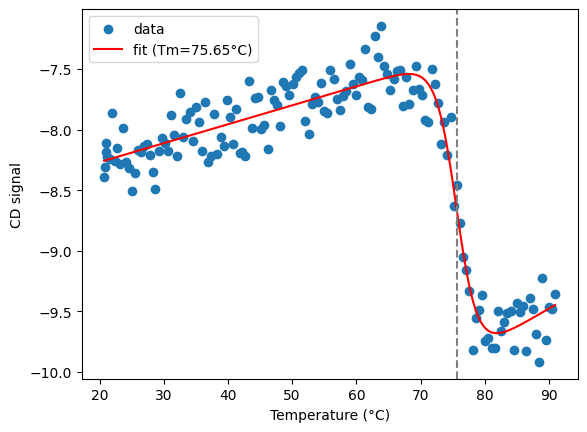

In [34]:
T_fit_sig_slope = np.linspace(T.min(), T.max(), 300)
Y_fit_sig_slope = sigmoid_slope(T_fit_sig_slope, *popt_sig_slope)

plt.scatter(T, Y, label="data")
plt.plot(T_fit_sig_slope, Y_fit_sig_slope, label=f"fit (Tm={Tm_fit_sig_slope:.2f}°C)", color='red')
plt.legend()
plt.xlabel("Temperature (°C)")
plt.ylabel("CD signal")
plt.axvline(Tm_fit_sig_slope, color='gray', linestyle='--', label=f'Tm = {Tm_fit_sig_slope:.2f}°C')

model_comparison["Sigmoid Slopes"] = {
    "Tm": Tm_fit_sig_slope,
    "T_fit": T_fit_sig_slope,
    "Y_fit": Y_fit_sig_slope
}
plt.show()

Plot the sigmoid with slopes result.

# Sigmoid model with slopes and fixed upper plateau

In [35]:

def model_fixed_upper(T, Tm, k, mf, bf, bu):
    exp_term = np.exp((T - Tm) / k)
    return ((mf*T + bf) + bu*exp_term) / (1 + exp_term)

p0_fixed_upper = [
    T[np.argmax(np.gradient(Y, T))],  # Tm
    2.0,                              # k
    0.0,                              # mf (flat-ish baseline)
    Y.min(),                          # bf
    Y[-5:].mean()                     # bu (estimate upper level)
]

**Model 4: Sigmoid with Slopes and Fixed Upper Plateau**

Compromise model: lower baseline can have a slope, but the unfolded state is fixed (no temperature dependence above Tm).

$f(T) = \frac{(m_f T + b_f) + b_u\, e^{\frac{T - T_m}{k}}}{1 + e^{\frac{T - T_m}{k}}}$

**When to use:** When the upper plateau is clearly flat (protein fully unfolded), or the upper plateau is not fully reached, but the lower baseline has a slope.

In [36]:
popt_fixed_upper, pcov_fixed_upper = curve_fit(model_fixed_upper, T, Y, p0=p0_fixed_upper, maxfev=10000)

Tm_fit_fixed_upper, k_fit_fixed_upper, mf_fit_fixed_upper, bf_fit_fixed_upper, bu_fit_fixed_upper = popt_fixed_upper

print(f"Fitted Tm with fixed upper baseline: {Tm_fit_fixed_upper:.2f} °C")

Fitted Tm with fixed upper baseline: 75.20 °C


Fit the model with fixed upper baseline.

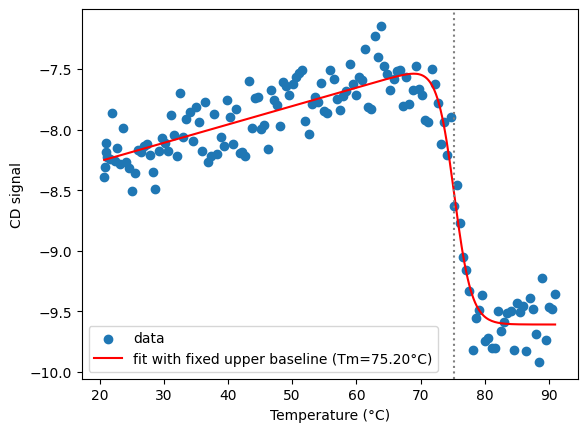

In [37]:
T_fit_fixed_upper = np.linspace(T.min(), T.max(), 300)
Y_fit_fixed_upper = model_fixed_upper(T_fit_fixed_upper, *popt_fixed_upper)

plt.scatter(T, Y, label="data")
plt.plot(T_fit_fixed_upper, Y_fit_fixed_upper, label=f"fit with fixed upper baseline (Tm={Tm_fit_fixed_upper:.2f}°C)", color='red')
plt.legend()
plt.xlabel("Temperature (°C)")
plt.ylabel("CD signal")
plt.axvline(Tm_fit_fixed_upper, color='gray', linestyle=':', label=f'Tm (fixed upper) = {Tm_fit_fixed_upper:.2f}°C')

model_comparison["Sigmoid Fixed Upper"] = {
    "Tm": Tm_fit_fixed_upper,
    "T_fit": T_fit_fixed_upper,
    "Y_fit": Y_fit_fixed_upper
}
plt.show()

Plot the fixed upper plateau result.

# Steepest slope

In [38]:
dYdT = np.gradient(Y, T)
if Y[0] < Y[-1]:
    Tm_slope = T[np.argmax(dYdT)]
else:
    Tm_slope = T[np.argmin(dYdT)]

Tm_slope

21.0187

**Model 5: Steepest Slope (First Derivative)**

Don't fit a model - just find where the steepest change occurs: Tm = max(dCD/dT).

**Advantage:** Model-free, doesn't assume sigmoid shape.

**Pitfall:** Very sensitive to noise. A single noisy point can shift the estimate. Hence smoothing is needed.

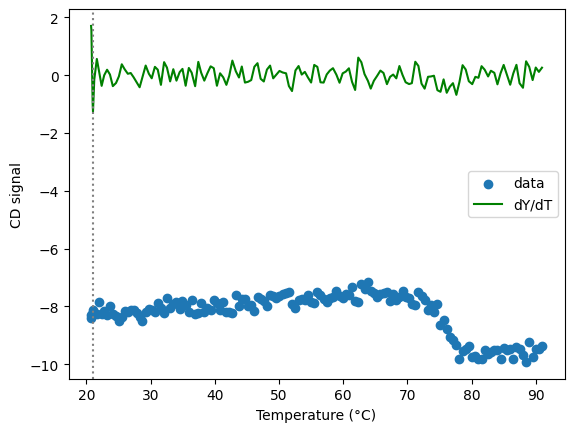

In [39]:
plt.scatter(T, Y, label="data")
plt.plot(T, dYdT, label="dY/dT", color='green')
plt.legend()
plt.xlabel("Temperature (°C)")
plt.ylabel("CD signal")
plt.axvline(Tm_slope, color='gray', linestyle=':', label=f'Tm (fixed upper) = {Tm_slope:.2f}°C')

model_comparison["Slope"] = {
    "Tm": Tm_slope,
    "T_fit": T,
    "Y_fit": dYdT
}
plt.show()

Plot CD data and its derivative to find steepest slope. Note the noise in dY/dT!

# Steepest slope on smoothed data

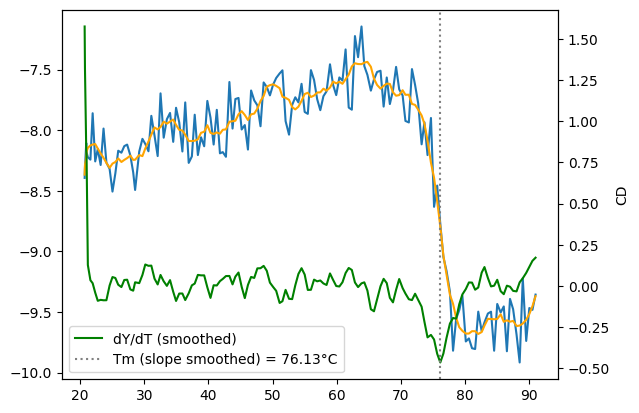

In [40]:
Y_smooth = savgol_filter(Y, 13, 3)

dYdT_smooth = np.gradient(Y_smooth, T)

if Y_smooth[0] < Y_smooth[-1]:
    Tm_slope_smooth = T[np.argmax(dYdT_smooth)]
else:
    Tm_slope_smooth = T[np.argmin(dYdT_smooth)]

plt.plot(T, Y, label="data")
plt.plot(T, Y_smooth, label="smoothed", color='orange')
plt.twinx()
plt.plot(T, dYdT_smooth, label="dY/dT (smoothed)", color='green')
plt.axvline(Tm_slope_smooth, color='gray', linestyle=':', label=f'Tm (slope smoothed) = {Tm_slope_smooth:.2f}°C')
plt.xlabel("Temperature")
plt.ylabel("CD")
plt.legend()
plt.show()

model_comparison["Slope (smoothed)"] = {
    "Tm": Tm_slope_smooth,
    "T_fit": T,
    "Y_fit": dYdT_smooth
}

**Model 6: Smoothed Derivative**

Apply Savitzky-Golay smoothing to the data first, then compute the derivative.

**Advantage:** Reduces noise-induced Tm errors while staying model-free.

**Pitfall:** The smoothing window (here 13 points) is a new parameter to tune. Too much smoothing loses the peak; too little keeps too much noise.

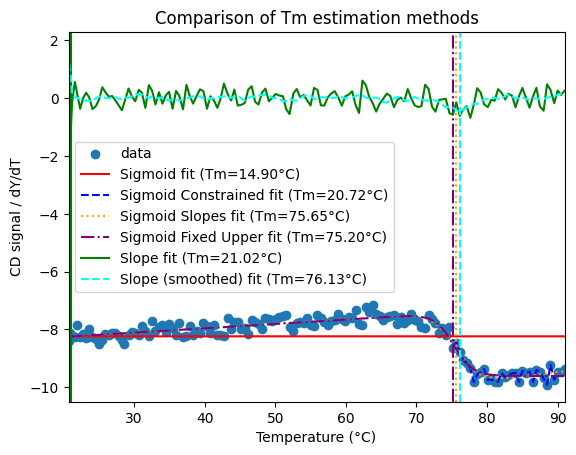

In [41]:
plt.scatter(T, Y, label="data")

colors = ['red', 'blue', 'orange', 'purple', 'green', 'cyan']
linestyles = ['-', '--', ':', '-.', '-', '--']
i = 0
for model_name, model_data in model_comparison.items():
    T_fit = model_data["T_fit"]
    Y_fit = model_data["Y_fit"]
    Tm = model_data["Tm"]
    plt.plot(T_fit, Y_fit, label=f"{model_name} fit (Tm={Tm:.2f}°C)", color=colors[i], linestyle=linestyles[i])
    plt.axvline(Tm, color=colors[i], linestyle=linestyles[i])
    i += 1


plt.legend()
plt.xlim(T.min(), T.max())

plt.xlabel("Temperature (°C)")
plt.ylabel("CD signal / dY/dT")
plt.title("Comparison of Tm estimation methods")


plt.show()

## Step 16: Compare All Models

Plot all fitted models together. This shows how different approaches agree or diverge.

**Good practice:** If all models give similar Tm, you can trust the result. Large divergence indicates noisy or incomplete data.

In [42]:
def calculate_Tm(wavelength, array_data, model_func, p0, maskbounds=None):
    curve = array_data["CircularDichroism"].sel(wavelength=wavelength)
    Abs   = array_data["Absorbance"].sel(wavelength=wavelength)

    ds_sel = curve.to_dataset(name="cd")
    ds_sel["abs"] = Abs

    ds_sel = ds_sel.where(ds_sel["abs"] < 2, drop=True)
    if maskbounds is not None:
        mask = (ds_sel["Temperature"] > maskbounds[0]) & (ds_sel["Temperature"] < maskbounds[1])
        ds_sel = ds_sel.where(mask, drop=True)
    ds_sel = ds_sel.dropna("Temperature").sortby("Temperature")

    T = ds_sel["Temperature"].values
    Y = ds_sel["cd"].values
    
    if len(T) < 10:
        return None

    try:
        popt, pcov = curve_fit(model_func, T, Y, p0=p0, maxfev=10000)
        perr = np.sqrt(np.diag(pcov))

    except RuntimeError:
        return None
    
    return popt, perr


# possible options for model_func and p0:
# model_func: simple_sigmoid, sigmoid_slope, model_fixed_upper
# p0: p0_sig, p0_sig_slope, p0_fixed_upper  

# possible combinations of model_func and p0:
# simple sigmoid: simple_sigmoid, p0_sig
# sigmoid with slopes: sigmoid_slope, p0_sig_slope
# sigmoid with fixed upper baseline: model_fixed_upper, p0_fixed_upper


## Step 17: Batch Calculate Tm for All Wavelengths

Define a helper function to fit a model across all wavelengths.

**Data structure challenge:** Must extract (Temperature, CD) pairs for each wavelength from the xarray, filter by absorbance, and handle missing data.

**Pitfall:** Some wavelengths may have too few valid points (<10) to fit reliably. The function returns None in these cases to skip them.

In [43]:
boundaries = [75, 90] # optional boundaries for masking the data

popt_func, perr_func = calculate_Tm(200, temperature_array, simple_sigmoid, p0_sig, boundaries)

popt_func

/tmp/ipykernel_3554557/2059142650.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model_func, T, Y, p0=p0, maxfev=10000)


array([  20.7191    ,    2.        , -784.15910115,  780.80482085])

Test the function on one wavelength (200 nm) to debug before running on all.

In [44]:
wavelengths = temperature_array["wavelength"].values

wavelengths

array([195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207,
       208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220,
       221, 222, 223, 224, 225, 226, 227, 228, 229, 230])

Extract all wavelengths from the xarray data structure.

In [150]:
mask = (
    ((wavelengths >= 200) & (wavelengths <= 240)) |
    ((wavelengths >= 223) & (wavelengths <= 223))
)

selected_wavelengths = wavelengths[mask]

boundaries = [60, 90] # optional boundaries for masking the data

results = []

p0=[60, 2.0, -8, -1.5, 0.0, -1.5] # Tm, k, mf, bf, mu, bu


for wl in selected_wavelengths:
    result = calculate_Tm(wl, 
                          temperature_array, 
                          sigmoid_slope, # simple_sigmoid, 
                          p0_sig_slope, # p0_sig, 
                          boundaries  # optional boundaries for masking the data
                          )

    if result is None:
        continue

    popt_func, perr_func = result

    results.append({
        "Wavelength": wl,
        "Tm": popt_func[0],
        "Tm_error": perr_func[0]
    })

results_df = pd.DataFrame(results)
print(results_df)


/tmp/ipykernel_3554557/1187815584.py:2: RuntimeWarning: overflow encountered in exp
  exp_term = np.exp((T - Tm) / k)
/tmp/ipykernel_3554557/1187815584.py:3: RuntimeWarning: invalid value encountered in divide
  return ((mf*T + bf) + (mu*T + bu)*exp_term) / (1 + exp_term)
/tmp/ipykernel_3554557/2059142650.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model_func, T, Y, p0=p0, maxfev=10000)
/tmp/ipykernel_3554557/2059142650.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model_func, T, Y, p0=p0, maxfev=10000)
/tmp/ipykernel_3554557/2059142650.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model_func, T, Y, p0=p0, maxfev=10000)
/tmp/ipykernel_3554557/2059142650.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model_func, T, Y, p0=p0, maxfev=10000)
/tmp/ipykernel_3554557/20591426

    Wavelength             Tm      Tm_error
0          200      50.856689           inf
1          201      74.888752  2.126132e-01
2          202   14322.060092           inf
3          203      74.916109  2.627757e-01
4          204  -29601.724233           inf
5          205  -80352.766572           inf
6          206  -26437.452038  4.736985e+10
7          207      74.890543  1.752149e-01
8          208      74.717084  4.991656e-01
9          209  110125.419516           inf
10         210      61.569581  1.247272e+02
11         211 -130752.067917           inf
12         212 -129542.478915  1.548256e+11
13         213  -55760.208925  7.714009e+10
14         214      55.397462  2.177535e+03
15         215      75.575431  4.149158e-01
16         216 -200898.418017  3.472396e+11
17         217 -162050.262182  2.608093e+11
18         218 -150760.245454           inf
19         219      75.633115  2.260721e-01
20         220      75.934476  3.209710e-01
21         221 -160191.874871   

/tmp/ipykernel_3554557/1187815584.py:2: RuntimeWarning: overflow encountered in exp
  exp_term = np.exp((T - Tm) / k)
/tmp/ipykernel_3554557/1187815584.py:3: RuntimeWarning: invalid value encountered in divide
  return ((mf*T + bf) + (mu*T + bu)*exp_term) / (1 + exp_term)
/tmp/ipykernel_3554557/2059142650.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model_func, T, Y, p0=p0, maxfev=10000)
/tmp/ipykernel_3554557/2059142650.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model_func, T, Y, p0=p0, maxfev=10000)


## Step 18: Fit All Wavelengths

Loop through selected wavelengths, fit the model, and extract Tm ± error for each.

**Data structure:** Collect results in a list of dicts, then convert to DataFrame.

**Pitfall Alert!** Some wavelengths may fail to fit (RuntimeError caught and skipped). Check the output to see how many succeeded vs. failed. If many fail, your data may be noisy or the model doesn't match the physics.

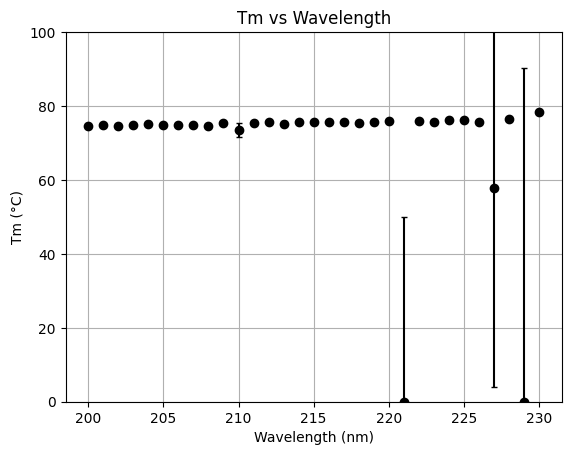

In [143]:
plt.errorbar(results_df["Wavelength"], 
             results_df["Tm"], 
             yerr=results_df["Tm_error"], 
             color='black', 
             label='Tm from fits', 
             fmt='o', 
             capsize=2)
if results_df["Tm"].max() < 100 and results_df["Tm"].min() > 0:
    plt.ylim(results_df["Tm"].min()-1, results_df["Tm"].max()+1)

else:
    plt.ylim(0, 100)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Tm (°C)")
plt.title("Tm vs Wavelength")
plt.grid()
plt.show()

Plot Tm values across wavelengths with error bars. Ideal result: all wavelengths give the same Tm with small error bars.

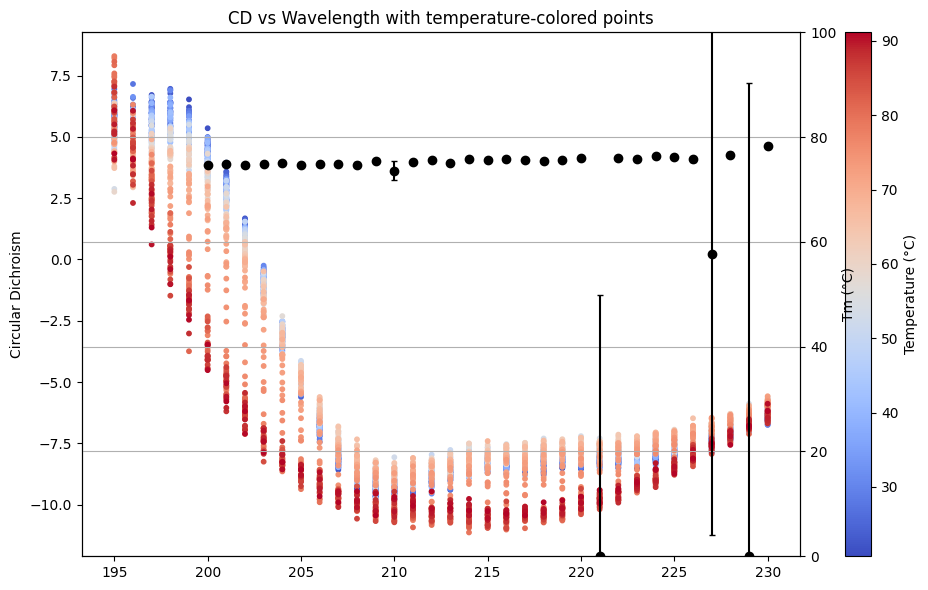

In [144]:
tmp = temperature_array["CircularDichroism"].where(temperature_array["Absorbance"]<2).to_dataframe().reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(tmp["wavelength"],
            tmp["CircularDichroism"],
            c=tmp["Temperature"],
            cmap="coolwarm",
            s=10
            )

plt.colorbar(label="Temperature (°C)")
plt.ylabel("Circular Dichroism")

plt.twinx()
plt.errorbar(results_df["Wavelength"], 
             results_df["Tm"], 
             yerr=results_df["Tm_error"], 
             color='black', 
             label='Tm from fits', 
             fmt='o',
             capsize=2
             )
plt.ylabel("Tm (°C)")

if results_df["Tm"].max() < 100 and results_df["Tm"].min() > 0:
    plt.ylim(results_df["Tm"].min()-1, results_df["Tm"].max()+1)

else:
    plt.ylim(0, 100)

plt.xlabel("Wavelength (nm)")

plt.title("CD vs Wavelength with temperature-colored points")
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 19: 2D Overlay - CD Signal and Tm Values

Combine the CD heatmap with fitted Tm values on top. This shows where the transitions occur and whether the fits make physical sense.

In [145]:
median = results_df["Tm"].median()
mad = np.median(np.abs(results_df["Tm"] - median))

# comparison score
z = (results_df["Tm"] - median) / mad

results_df_clean = results_df[np.abs(z) < 3]

results_df_clean

,Wavelength,Tm,Tm_error
0,200,74.705542,0.286438
1,201,74.888779,0.212591
2,202,74.697016,0.289488
3,203,74.916106,0.262778
4,204,75.147397,0.240421
5,205,74.737119,0.334240
6,206,74.825733,0.328232
7,207,74.890529,0.175198
8,208,74.717078,0.499173
9,209,75.413579,0.285663


## Step 20: Outlier Detection with Median Absolute Deviation (MAD)

**Pitfall Alert!** Some wavelengths may give anomalous Tm values due to:
- Poor data quality at that wavelength
- Failed fit convergence
- Spectral features unrelated to unfolding

Use MAD (more robust than standard deviation for non-normal distributions) to identify and remove outliers.

**Rule:** Keep only wavelengths where |Tm - median| / MAD < 3 (robust z-score).

In [146]:
weights = 1 / results_df_clean["Tm_error"]**2
Tm = np.sum(weights * results_df_clean["Tm"]) / np.sum(weights)
Tm_err = results_df_clean["Tm"].std()

print(f"Estimated Tm: {Tm:.2f} ± {Tm_err:.2f} °C")

Estimated Tm: 75.41 ± 0.55 °C


## Step 21: Final Tm Estimate with Weighted Average

**Data structure and pitfall:** Combine Tm estimates from multiple wavelengths using inverse-variance weighting:

$T_m = \frac{\sum_i w_i\, T_{m,i}}{\sum_i w_i}, \quad w_i = \frac{1}{\sigma_i^2}$

This gives more weight to wavelengths with precise fits and less weight to noisy ones.

**Important:** After outlier removal, estimate error as std(Tm_clean), not from fitting alone!

In [147]:
results_df_clean

#remove inf values from results_df_clean
results_df_clean = results_df_clean.replace([np.inf, -np.inf], np.nan).dropna()

Show the cleaned results (outliers removed).

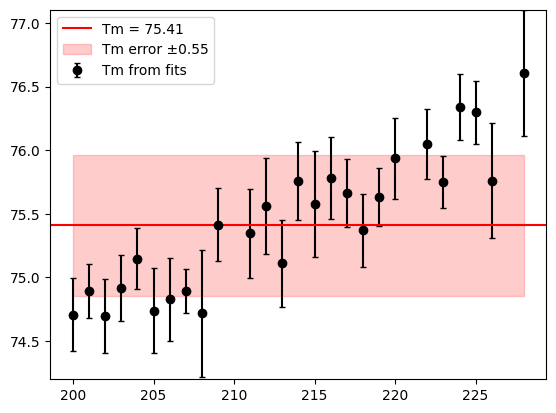

In [148]:
plt.errorbar(results_df_clean["Wavelength"], results_df_clean["Tm"], yerr=results_df_clean["Tm_error"], fmt='o', capsize=2, color='black', label='Tm from fits')
plt.axhline(Tm, color='r', label=f"Tm = {Tm:.2f}")

plt.fill_between(results_df_clean["Wavelength"], 
                 Tm - Tm_err, 
                 Tm + Tm_err, 
                 color='r', 
                 alpha=0.2, 
                 label=f"Tm error ±{Tm_err:.2f}"
                 )
if results_df_clean["Tm"].max() < 100 and results_df_clean["Tm"].min() > 0:
    plt.ylim(results_df_clean["Tm"].min()-results_df_clean["Tm_error"].max(), 
             results_df_clean["Tm"].max()+results_df_clean["Tm_error"].max())
else:
    plt.ylim(0, 100)
plt.legend()
plt.show()

## Step 22: Final Result

Plot the cleaned Tm values with the weighted average and uncertainty band. This is the final **Tm ± σ** estimate.

**Summary of the workflow:**
1. Load multi-wavelength temperature scan data ✓
2. Organize into 2D (Temperature × Wavelength) structure (xarray) ✓
3. Test multiple fitting models to extract Tm at each wavelength ✓
4. Remove outliers using MAD criterion ✓
5. Combine results using inverse-variance weighting ✓

**Key takeaways:**
- Data structures matter! xarray makes multi-dimensional data easier to handle
- Always test multiple models and compare results
- Outliers can come from bad data, poor fits, or failed measurements - investigate them!
- Combine wavelength results with proper weighting to get a robust final answer

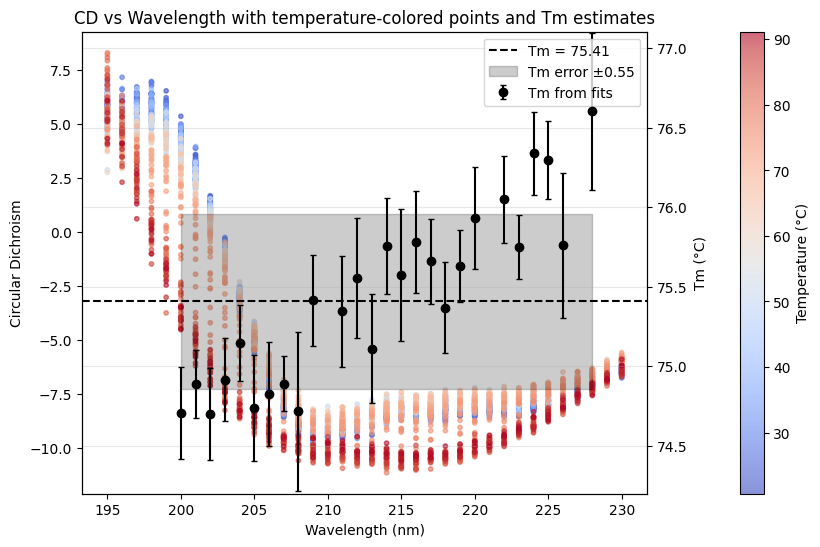

In [149]:
tmp = temperature_array["CircularDichroism"].where(temperature_array["Absorbance"]<2).to_dataframe().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

scatter = ax1.scatter(tmp["wavelength"],
                      tmp["CircularDichroism"],
                      c=tmp["Temperature"],
                      cmap="coolwarm",
                      s=10,
                      alpha=0.6)


ax1.set_ylabel("Circular Dichroism")
ax1.set_xlabel("Wavelength (nm)")

ax2.errorbar(results_df_clean["Wavelength"], 
             results_df_clean["Tm"], 
             yerr=results_df_clean["Tm_error"], 
             fmt='o', 
             capsize=2, 
             color='black', 
             label='Tm from fits',
             zorder=5)

ax2.axhline(Tm, 
            color='k', 
            linestyle='--',
            label=f"Tm = {Tm:.2f}")

ax2.fill_between(results_df_clean["Wavelength"], 
                 Tm - Tm_err, 
                 Tm + Tm_err, 
                 color='k', 
                 alpha=0.2, 
                 label=f"Tm error ±{Tm_err:.2f}")

if results_df_clean["Tm"].max() < 100 and results_df_clean["Tm"].min() > 0:
    ax2.set_ylim(results_df_clean["Tm"].min()-results_df_clean["Tm_error"].max(), 
                 results_df_clean["Tm"].max()+results_df_clean["Tm_error"].max())
else:
    ax2.set_ylim(0, 100)

ax2.set_ylabel("Tm (°C)")
ax2.legend(loc='upper right')
ax2.set_title("CD vs Wavelength with temperature-colored points and Tm estimates")
ax2.grid(True, alpha=0.3)

cbar = fig.colorbar(scatter, ax=ax1, pad=0.12)
cbar.set_label("Temperature (°C)")

plt.show()